# Challenges Week 8


In today's challenge, we will go back to the YouBike data (https://data.gov.tw/dataset/67784). The dataset of this week, `youbike.csv`, contains information about YouBike usage in Hsinchu. I have already done some data wrangling for you so you have only the data from NYCU and calculated the monthly average (while fixing the string issues).

#### Challenge 1

* Let's get to know the data. Plot monthly usage over time.
* Found anything weird? Luckily we visualised the data. Don't expect data to be error-free. Use the follow codes to remove the problematic rows:
```
df = df[df["monthly_avg"] <= 500]
```

* Let's add station comparison (color them by station using `hue=`)
* Create separate plots for each station using facet (remember we need something like this `sns.relplot( ...  col="somevariable"`)

#### Challenge 2

* Is there any seasonality patterns? Make a new variable called `month`
* Compare the months using a barplot
* Make a `jointplot()` to see if there are relationship between "日期1日使用筆數" and "日期21日使用筆數" (well, people might bike less towards the end of the month since they generally became "poorer")?

#### Challenge 3

* Now it's your turn, try to dig

In [2]:
# Loading libraries
import pandas as pd
import seaborn as sns

/Users/justin/Library/jupyterlab-desktop/jlab_server/lib/python3.12/site-packages/seaborn/_statistics.py:32: UserWarning: A NumPy version >=1.23.5 and <2.3.0 is required for this version of SciPy (detected version 2.3.2)
  from scipy.stats import gaussian_kde


In [39]:
# 0. reading the data
df = pd.read_csv('youbike.csv')

# 1. filter stations containing 交通大學
df_filtered = df[df["場站名稱"].astype(str).str.contains("交通大學", na=False)].copy()

# 2. find all daily usage columns
day_cols = [c for c in df.columns if c.startswith("日期") and c.endswith("日使用筆數")]

# 3. coerce strings to numeric (yup, it contains string when non-operation)
df_filtered[day_cols] = df_filtered[day_cols].apply(pd.to_numeric, errors="coerce")

# 4. calculate monthly average
df_filtered["monthly_avg"] = df_filtered[day_cols].mean(axis=1)

df_filtered.head()

,縣市別代碼,機關代碼,所屬年月,場站編號,場站名稱,日期1日使用筆數,日期2日使用筆數,日期3日使用筆數,日期4日使用筆數,日期5日使用筆數,...,日期23日使用筆數,日期24日使用筆數,日期25日使用筆數,日期26日使用筆數,日期27日使用筆數,日期28日使用筆數,日期29日使用筆數,日期30日使用筆數,日期31日使用筆數,monthly_avg
4,10018,376580000A,202601,500401005,陽明交通大學(大學路),58.0,57.0,54.0,75.0,107.0,...,70.0,77.0,81.0,95.0,86.0,92.0,117.0,102.0,58.0,85.000000
5,10018,376580000A,202601,500401006,陽明交通大學(逐風廣場),28.0,21.0,35.0,37.0,68.0,...,58.0,35.0,30.0,69.0,69.0,80.0,64.0,60.0,32.0,51.387097
31,10018,376580000A,202601,500401032,陽明交通大學(研三舍),43.0,47.0,40.0,57.0,66.0,...,37.0,53.0,86.0,67.0,60.0,67.0,86.0,73.0,45.0,56.387097
53,10018,376580000A,202601,500401055,陽明交通大學(博愛校區),40.0,55.0,48.0,37.0,78.0,...,82.0,40.0,22.0,40.0,34.0,40.0,53.0,58.0,32.0,62.548387
125,10018,376580000A,202512,500401005,陽明交通大學(大學路),124.0,122.0,96.0,118.0,115.0,...,110.0,98.0,41.0,103.0,76.0,77.0,94.0,110.0,60.0,101.419355


In [13]:
# Just run this, it will search for one of the fonts that you have installed in your system
# PS: doing things in non-English is always a pain

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

def setup_cjk_font():
    candidates = [
        'Noto Sans CJK TC',
        'Noto Sans CJK SC',
        'Noto Sans CJK JP',
        'Microsoft JhengHei',
        'PingFang TC',
        'SimHei',
        'Arial Unicode MS'
    ]
    
    available = {f.name for f in fm.fontManager.ttflist}
    
    for font in candidates:
        if font in available:
            plt.rcParams['font.family'] = 'sans-serif'
            plt.rcParams['font.sans-serif'] = [font]
            plt.rcParams['axes.unicode_minus'] = False
            print(f'Using font: {font}')
            return font
    
    print('No CJK font found by matplotlib.')
    return None

setup_cjk_font()

Using font: Arial Unicode MS


'Arial Unicode MS'

# Challenge 2

Create a new column called `word_count` which counts the number of characters in `description` (remember the `len()` function?). Which shop has most words in the description?



In [52]:
df_filtered['month'] = [str(x)[4:] for x in df_filtered['所屬年月']]

In [53]:
df_filtered['month']

4       01
5       01
31      01
53      01
125     12
        ..
7017    06
7021    06
7054    05
7087    04
7120    03
Name: month, Length: 335, dtype: str

<Axes: xlabel='日期1日使用筆數', ylabel='日期21日使用筆數'>

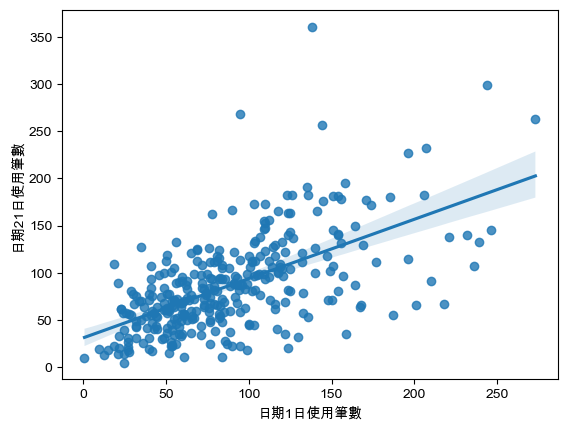

In [56]:
sns.regplot(data = df_filtered, x = '日期1日使用筆數', y='日期21日使用筆數')

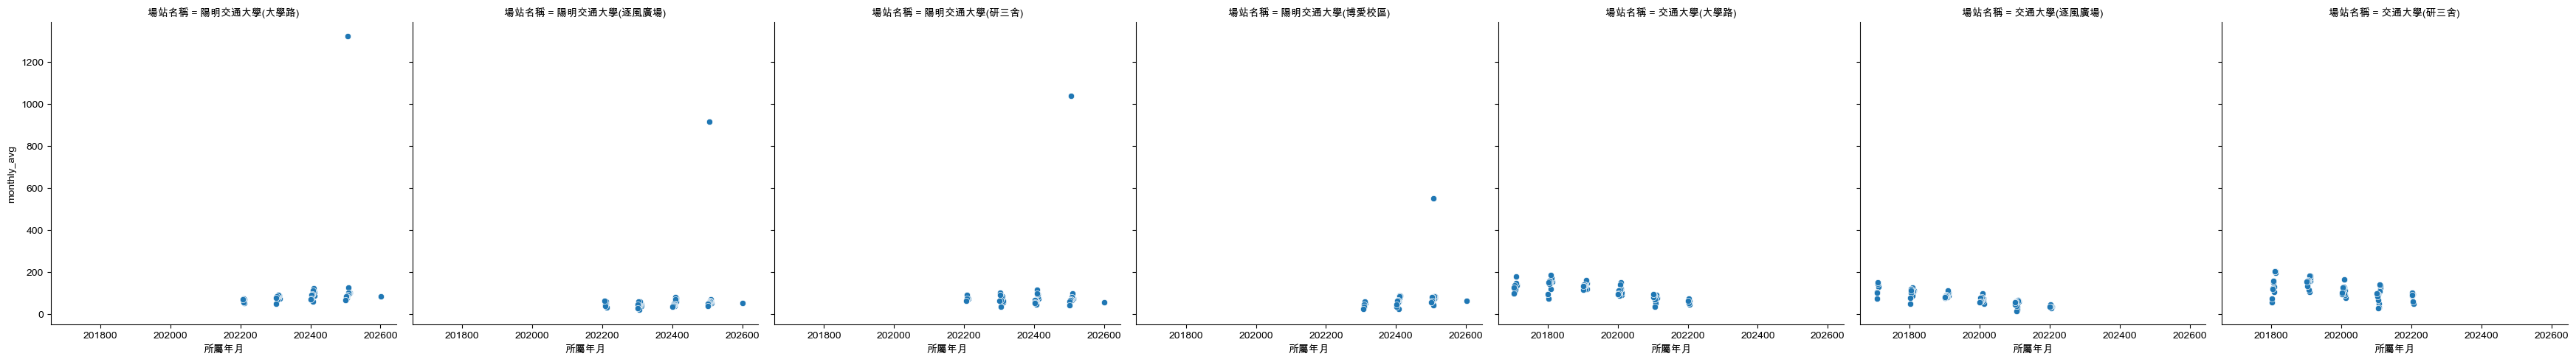

In [22]:
sns.relplot( data=df_filtered, x="所屬年月", y="monthly_avg", col="場站名稱")


In [20]:
df_filtered[df_filtered['monthly_avg'] > 200]

,縣市別代碼,機關代碼,所屬年月,場站編號,場站名稱,日期1日使用筆數,日期2日使用筆數,日期3日使用筆數,日期4日使用筆數,日期5日使用筆數,...,日期23日使用筆數,日期24日使用筆數,日期25日使用筆數,日期26日使用筆數,日期27日使用筆數,日期28日使用筆數,日期29日使用筆數,日期30日使用筆數,日期31日使用筆數,monthly_avg
802,10018,376580000A,202506,500401005,陽明交通大學(大學路),1220.0,1160.0,910.0,1040.0,1450.0,...,1940.0,2160.0,1810.0,1010.0,1090.0,760.0,650.0,1600.0,NaN,1325.333333
803,10018,376580000A,202506,500401006,陽明交通大學(逐風廣場),2190.0,880.0,480.0,880.0,580.0,...,1000.0,1580.0,950.0,1000.0,800.0,620.0,580.0,1200.0,NaN,916.000000
829,10018,376580000A,202506,500401032,陽明交通大學(研三舍),1030.0,1220.0,780.0,1020.0,1540.0,...,1020.0,1100.0,1120.0,1160.0,580.0,680.0,350.0,900.0,NaN,1040.000000
851,10018,376580000A,202506,500401055,陽明交通大學(博愛校區),520.0,620.0,310.0,370.0,290.0,...,720.0,930.0,400.0,380.0,370.0,420.0,300.0,580.0,NaN,550.333333
6204,10018,376580000A,201812,6147,交通大學(研三舍),273.0,222.0,166.0,175.0,205.0,...,96.0,168.0,198.0,160.0,188.0,314.0,178.0,139.0,161.0,202.709677
6302,10018,376580000A,201810,6147,交通大學(研三舍),196.0,171.0,209.0,77.0,336.0,...,191.0,198.0,224.0,340.0,243.0,194.0,159.0,152.0,124.0,202.580645
6351,10018,376580000A,201809,6147,交通大學(研三舍),138.0,121.0,221.0,207.0,202.0,...,139.0,197.0,166.0,122.0,138.0,202.0,224.0,233.0,NaN,202.200000


# Challenge 3

The column `closed_on` contains information about closing days. 
Tips: some dates are written in Dutch, "zondag" means Sunday in English.

How many shops can I choose from if I want to drink bubble tea on Sunday?
- Write a new function that will return either `"Open on Sunday"` or `"Closed on Sunday"`
- Create a column, `sunday_closed`, to denote if the shop will open on Sunday
- Createa a new dataset with only the stores that open on Sunday
- Write a csv file with the dataset you ended up with. 